# Project 1: Loan Approval Prediction (Classification)

This project builds an end-to-end binary classification model to predict whether a loan application will be approved based on applicant details. It covers:
*   Data cleaning and boxplot analysis for outlier detection.
*   Preprocessing pipelines using `OneHotEncoder` and `MinMaxScaler`.
*   Model training using `LogisticRegression`.
*   Comprehensive performance evaluation (Precision, Recall, F1-Score, and Confusion Matrix).

In [88]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler
import seaborn as sns


In [89]:
df=pd.read_csv('Loan_approval_dataset.csv')

In [90]:
df.head()

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No


In [91]:
X = df.drop(columns='Loan_Approved') #dropping loan approved col to select all other col as feature columns
y = df.Loan_Approved #Target col

In [92]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,random_state=42,train_size=0.8)

In [93]:
#correlation btw features
X.corr(numeric_only=True)   #weakly correlated(no multicollinearity)

,Age,Salary,Credit_Score,Loan_Amount
Age,1.000000,0.060125,-0.018835,-0.000500
Salary,0.060125,1.000000,-0.011185,-0.000635
Credit_Score,-0.018835,-0.011185,1.000000,0.008741
Loan_Amount,-0.000500,-0.000635,0.008741,1.000000


In [94]:
#segregating to apply preprocessing technique
num_cols=X.select_dtypes(include='number').columns
obj_cols=X.select_dtypes(include='object').columns

<Axes: >

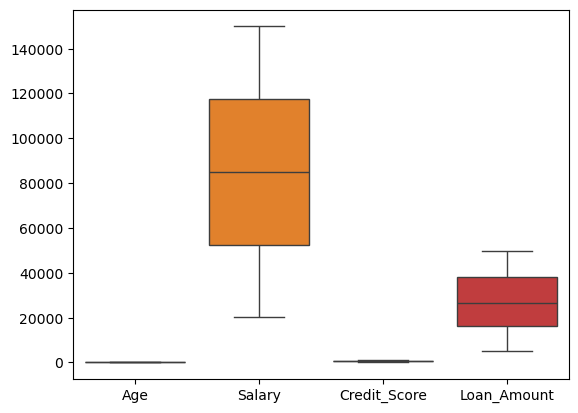

In [95]:
#for numerical col
sns.boxplot(X[num_cols])

In [96]:
X[obj_cols].nunique()  #less unique values so v can use OneHotEncoder

Loan_Term            4
Employment_Status    3
Residence_Type       3
Previous_Default     2
dtype: int64

Preprocessing Techniques

-Scaling

-Encoding

why Scaling? - 'Feature(numerical) cols' values are in different range(scale).So we can use scaling to equal importance for all the feature columns.

Why encoding? - 'Algorithms can understand only numbers not strings'

which scaling and Encoding Techniques we can use for this?

Scaling - 1)'MinMaxScaler', 2)'StandardScaler'

Encoding - 

Loan_Term              4

Employment_Status      3

Residence_Type         3

Previous_Default       2

dtype: int64 

unique values are less so we can use OneHotEncoder


In [97]:
encoder=OneHotEncoder(sparse_output=False,handle_unknown='ignore') #to handle unknown values,by default error and it assigns 0 to unknown values
scaling=MinMaxScaler()
model=LogisticRegression()

In [98]:
#Train the model
#model.fit(xtrain,ytrain)  #ValueError: could not convert string to float: '24 months'

#Xtrain
xtrain[num_cols]=scaling.fit_transform(xtrain[num_cols])
#xtrain[obj_cols]=encoder.fit_transform(xtrain[obj_cols]) #valueError
encoded_values=encoder.fit_transform(xtrain[obj_cols])
encoded_columns=encoder.get_feature_names_out()

xtrain[encoded_columns]=encoded_values
xtrain.drop(columns=obj_cols,inplace=True)

In [99]:
#Updated xtrain
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
29,0.565217,0.503206,0.377737,0.267437,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
535,0.434783,0.517503,0.344891,0.125955,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
695,0.586957,0.227507,0.843066,0.766342,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
557,0.630435,0.425421,0.928832,0.792145,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
836,0.608696,0.623919,0.372263,0.599124,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.739130,0.759429,0.709854,0.592266,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
270,0.173913,0.889773,0.160584,0.388186,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
860,1.000000,0.884776,0.698905,0.078281,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
435,0.173913,0.213857,0.987226,0.906103,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [100]:
#Xtest
xtest[num_cols]=scaling.transform(xtest[num_cols])
#xtrain[obj_cols]=encoder.transform(xtrain[obj_cols]) #valueError
encoded_values=encoder.transform(xtest[obj_cols])
#encoded_columns=encoder.get_feature_names_out()

xtest[encoded_columns]=encoded_values
xtest.drop(columns=obj_cols,inplace=True)

In [101]:
xtest

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term_12 months,Loan_Term_24 months,Loan_Term_36 months,Loan_Term_48 months,Employment_Status_Employed,Employment_Status_Self-Employed,Employment_Status_Unemployed,Residence_Type_Mortgage,Residence_Type_Owned,Residence_Type_Rented,Previous_Default_No,Previous_Default_Yes
521,0.152174,0.220886,0.521898,0.540280,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
737,0.434783,0.687894,0.020073,0.453711,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
740,0.347826,0.836468,0.760949,0.652294,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
660,0.434783,0.315031,0.950730,0.116550,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
411,0.934783,0.605720,0.693431,0.587172,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408,0.782609,0.894307,0.270073,0.867633,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
332,0.347826,0.976689,0.764599,0.938296,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
208,0.478261,0.012071,0.034672,0.038805,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
613,0.086957,0.540937,0.791971,0.830012,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


In [102]:
model.fit(xtrain,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [103]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix
import numpy as np

Train Data Evaluation

In [104]:
ypred_train=model.predict(xtrain)
matrix=confusion_matrix(ytrain,ypred_train)

In [105]:
ytrain.value_counts()

Loan_Approved
Yes    403
No     397
Name: count, dtype: int64

conclusion: model is not correctly predicting the labels 50-50


In [106]:
#precision_score(ytrain,ypred_train) #by default it check for 1
precision_score(ytrain,ypred_train,pos_label='Yes')  #54% model predicts

0.548235294117647

In [107]:
predicted_yes=np.sum(matrix[:,1])
np.sum(matrix[:,0])

375

Conclusion: 

out of all the predicted 'yes' label(425),54% labels are correctly predicted as 'yes.

out of all the predicted 'yes' labels(425),46% labels are wrongly predicted as 'yes'.

In [108]:
predicted_no=np.sum(matrix[:,0])

Conclusion

out of all the predicted 'no' labels(375),54% labels are correctly predicted as no

out of all the predicted 'no' labels(375),46% labels are wrongly predicted as no

In [109]:
recall_score(ytrain,ypred_train,pos_label='Yes')

0.5781637717121588

Conclusion

out of all the actual Yes labels(375),54% labels are correctly predicted as yes

out of all the actual Yes labels(375),46% labels are wrongly predicted as NO

In [110]:
accuracy_score(ytrain,ypred_train)

0.5475

Conclusion:
out of all the samples(800),54.75% samples are correctly predicted

Final Conclusion

Model performance on train data is bad,so model is not learned train data pattern properly

model performance is underfit,and bias is high and variance is low,model is too simple not able to capture the complex pattern

In [111]:
ypred_test=model.predict(xtest)
matrix=confusion_matrix(ytest,ypred_test)

In [112]:
from sklearn.metrics import classification_report

In [113]:
print((classification_report)(ytrain,ypred_train))

              precision    recall  f1-score   support

          No       0.55      0.52      0.53       397
         Yes       0.55      0.58      0.56       403

    accuracy                           0.55       800
   macro avg       0.55      0.55      0.55       800
weighted avg       0.55      0.55      0.55       800



### macro(average)

Takes the avg of precision score and predicts overall conclusion for the entire samples,out of all how many samples are correctly predicted.

when labels have imbalance samples in f1_score we need to check the macro avg.

### weighted average

it uses support along with the average of both yes and no

In [114]:
print(classification_report(ytest,ypred_test))

              precision    recall  f1-score   support

          No       0.47      0.49      0.48        95
         Yes       0.52      0.50      0.51       105

    accuracy                           0.49       200
   macro avg       0.49      0.49      0.49       200
weighted avg       0.50      0.49      0.50       200



Preprocessing techniques:polynomial,encoder,scaler

### column transform - transfer all the feature together(feature preprocessing technique)

target encoder - unique value

minmax scaler - no outliers

robust scaler - more outliers


### Note: 

It is a ML technique which combines multiple preprocessing and executes parallely

In column transformer we use only preprocessing technique not an algorithm

### Syntax:

from sklearn.compose import columnTransformer

preprocessing=ColumnTransformer(

    transformers=[

        ('name of the preprocessing',preprocessing,col_names)

        ('name of the preprocessing',preprocessing,col_names)],

        remainder(optional)='drop'\'pass through')

### Example:

preprocessing=ColumnTransformer (

    transformers=[

        ('minmax_scaling',MinMaxScaler(),['f1','f2']),
        
        ('Robust_scaling',RobustScaler(),['f3','f4']),

        ('encoder',TargetEncoder(),['f5','f6'])

    ]
    
)

Xtrain_new=preprocessing.fit_transform(Xtrain)

minmax return 2 cols, robust returns 2 cols, target returns 2 cols, at last column transformer combines all the column values get one dataframe that we are storing in xtrain

Advantage: 
no need to transform again and again

### Remainder - drop and pass through

remainder by default it drop 2 columns and only 4 cols are stored.

if any col names are not mentioned in transformer,it drop that col values

remainder pass through - we get all 6 columns without droping 


